In [2]:
import pandas as pd

df = pd.read_csv("../../data/kaggle_pipeline.csv")

print("Veri başarıyla yüklendi. Toplam satır sayısı:", len(df))
df.head()

Veri başarıyla yüklendi. Toplam satır sayısı: 10000


,OyuncuID,OturumSayisi,OyuncuSeviyesi,TotalSatınAlma,Ortalama_Oturum_Suresi,OyunaBaglilik,Toplam_Oyun_Suresi,Oturum_Basina_Harcama,Churn
0,43667,16,43,1,63,Medium,1008,0.0625,0
1,31227,10,48,0,99,Medium,990,0.0000,0
2,33899,11,12,0,17,Medium,187,0.0000,0
3,44415,7,44,0,149,Medium,1043,0.0000,0
4,30440,10,14,0,127,Medium,1270,0.0000,0


In [3]:
sutunlar_to_drop = ['Churn', 'OyuncuID', 'OyunaBaglilik']

X = df.drop(columns=[col for col in sutunlar_to_drop if col in df.columns])

y = df['Churn']

print("Modelin kullanacağı girdiler sütun sayısı:", X.shape[1])
print("Sütunların Listesi:", X.columns.tolist())

Modelin kullanacağı girdiler sütun sayısı: 6
Sütunların Listesi: ['OturumSayisi', 'OyuncuSeviyesi', 'TotalSatınAlma', 'Ortalama_Oturum_Suresi', 'Toplam_Oyun_Suresi', 'Oturum_Basina_Harcama']


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train Set Boyutu: {X_train.shape}")
print(f"Test Set Boyutu: {X_test.shape}")

Train Set Boyutu: (8000, 6)
Test Set Boyutu: (2000, 6)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

print("=== BASELINE MODEL (LOGISTIC REGRESSION) PERFORMANSI ===")
print(classification_report(y_test, y_pred_baseline))


=== BASELINE MODEL (LOGISTIC REGRESSION) PERFORMANSI ===
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      1480
           1       0.86      0.82      0.84       520

    accuracy                           0.92      2000
   macro avg       0.90      0.88      0.89      2000
weighted avg       0.92      0.92      0.92      2000



In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== AĞAÇ TABANLI MODEL (RANDOM FOREST) PERFORMANSI ===")
print(classification_report(y_test, y_pred_rf))

=== AĞAÇ TABANLI MODEL (RANDOM FOREST) PERFORMANSI ===
              precision    recall  f1-score   support

           0       0.95      0.96      0.95      1480
           1       0.88      0.84      0.86       520

    accuracy                           0.93      2000
   macro avg       0.91      0.90      0.91      2000
weighted avg       0.93      0.93      0.93      2000



In [8]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')

print("=== ÇAPRAZ DOĞRULAMA SONUÇLARI ===")
print("Her bir katın F1 Skoru:", cv_scores)
print(f"Ortalama F1 Skoru: {cv_scores.mean():.4f}")
print(f"F1 Skorlarının Standart Sapması: {cv_scores.std():.4f}")

=== ÇAPRAZ DOĞRULAMA SONUÇLARI ===
Her bir katın F1 Skoru: [0.84146341 0.84819277 0.82439024 0.8667467  0.85012285]
Ortalama F1 Skoru: 0.8462
F1 Skorlarının Standart Sapması: 0.0137


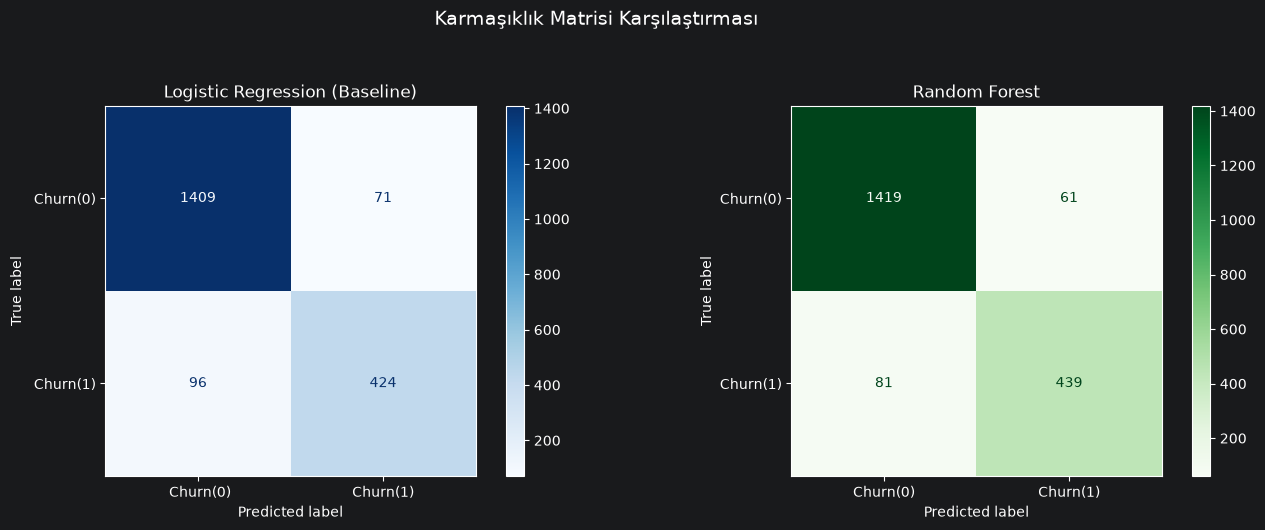

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_base = confusion_matrix(y_test, y_pred_baseline)
disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=[" Churn(0)", "Churn(1)"])
disp_base.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Logistic Regression (Baseline)')

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Churn(0)", "Churn(1)"])
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Random Forest')

plt.suptitle('Karmaşıklık Matrisi Karşılaştırması', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

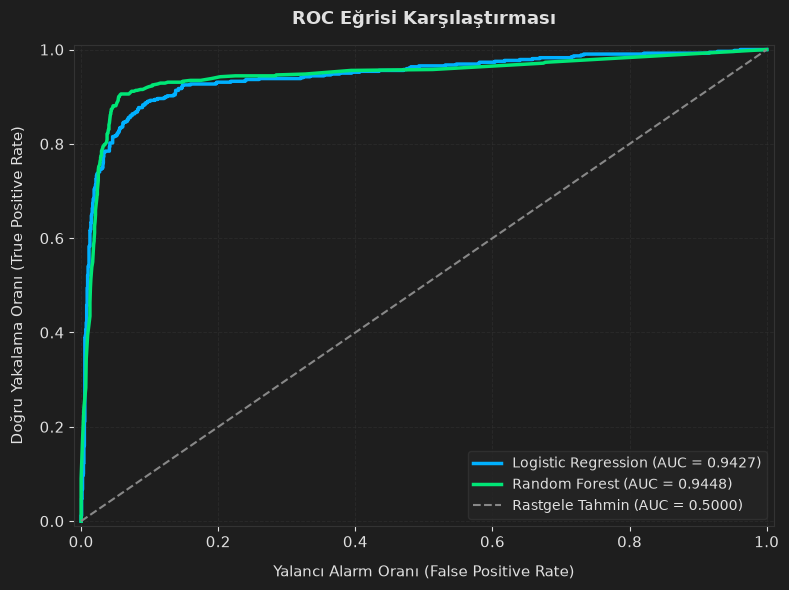

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

y_probs_base = baseline_model.predict_proba(X_test)[:, 1]
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

fpr_base, tpr_base, _ = roc_curve(y_test, y_probs_base)
auc_base = auc(fpr_base, tpr_base)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_probs_rf)
auc_rf = auc(fpr_rf, tpr_rf)

dark_bg = '#1e1e1e'
text_color = '#e0e0e0'

fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
fig.patch.set_facecolor(dark_bg)
ax.set_facecolor(dark_bg)

ax.plot(fpr_base, tpr_base, color='#00b0ff', linewidth=2.5,
        label=f'Logistic Regression (AUC = {auc_base:.4f})')
ax.plot(fpr_rf, tpr_rf, color='#00e676', linewidth=2.5,
        label=f'Random Forest (AUC = {auc_rf:.4f})')

ax.plot([0, 1], [0, 1], color='#888888', linestyle='--', linewidth=1.5, label='Rastgele Tahmin (AUC = 0.5000)')


ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])
ax.xaxis.grid(True, color='#333333', linestyle='--', linewidth=0.7)
ax.yaxis.grid(True, color='#333333', linestyle='--', linewidth=0.7)

for spine in ax.spines.values():
    spine.set_color('#333333')

ax.tick_params(colors=text_color, which='both', labelsize=11)
ax.set_xlabel('Yalancı Alarm Oranı (False Positive Rate)', color=text_color, fontsize=11, labelpad=10)
ax.set_ylabel('Doğru Yakalama Oranı (True Positive Rate)', color=text_color, fontsize=11, labelpad=10)
ax.set_title('ROC Eğrisi Karşılaştırması', color=text_color, fontsize=13, fontweight='bold', pad=15)


legend = ax.legend(loc='lower right', facecolor='#252525', edgecolor='#333333', fontsize=10)
plt.setp(legend.get_texts(), color=text_color)

plt.tight_layout()
plt.show()